<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Time_series_basics_from_AI/Phase1_Timeseries_Anatomy_and_Stationarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)

#####Load Airpassenger dataset

In [ ]:
# Loading the AirPassengers dataset from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

In [ ]:
df = pd.read_csv(url)
df.head(10)
df.tail(10)

,Month,Passengers
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [ ]:
df.shape

(144, 2)

In [ ]:
df.dtypes

,0
Month,object
Passengers,int64


In [ ]:
#converting month column to date
df["Month"] = pd.to_datetime(df["Month"])

#set index month column
df = df.set_index("Month")



In [ ]:
display(df.head())

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


#####Plot raw time series

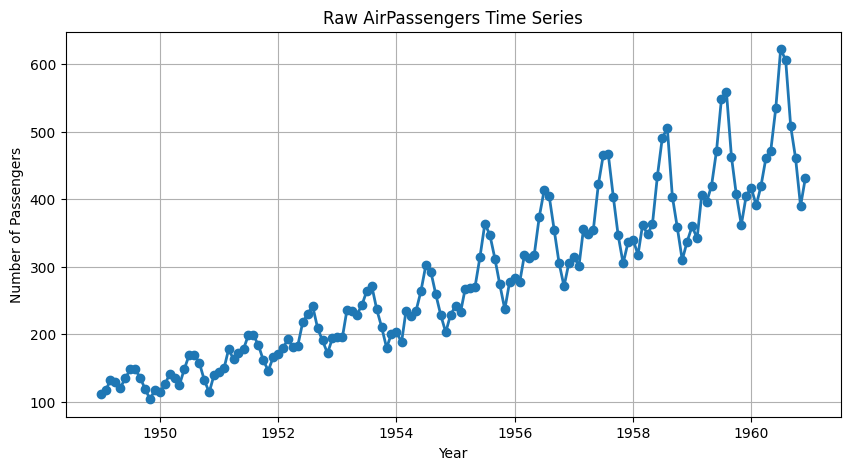

In [ ]:
# Plotting the raw passenger time series
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Passengers"], marker="o", linewidth=2)
plt.title("Raw AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

**Question:what trend do you see? What seasonality?**

The raw AirPassengers series shows a clear upward trend: the number of passengers increases over time.

The series also shows strong yearly seasonality: passenger numbers rise and fall in a repeated pattern every 12 months.

#####ADF Helper Funcion

In [ ]:
# Creating a function to run the ADF test and print a clean report
def adf_report(series, name="Series"):
    series = series.dropna() #removes missing value of NaN
    result = adfuller(series) #adfuller function applied
    adf_statistic = result[0] # 0 keeps he adf statistics value
    p_value = result[1]       # 1 = p_value
    used_lag = result[2]      # 2 = lag_value
    n_obs = result[3]         # 3 = observaions
    critical_values = result[4] #4 = critical value

    print("=" * 60)
    print(f"ADF Test Report: {name}")
    print("=" * 60)
    print(f"ADF Statistic : {adf_statistic:.4f}")
    print(f"p-value       : {p_value:.4f}")
    print(f"Used Lag      : {used_lag}")
    print(f"Observations  : {n_obs}")
    print("\nCritical Values:")

    for key, value in critical_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value <= 0.05:
        verdict = "Stationary"
        print("\nVerdict: Reject H0. The series is likely stationary.")
    else:
        verdict = "Non-stationary"
        print("\nVerdict: Fail to reject H0. The series is likely non-stationary.")

    return {
        "Series": name,
        "ADF Statistic": adf_statistic,
        "p-value": p_value,
        "Verdict": verdict
    }

In [ ]:
# Running ADF test on the raw passenger series
raw_adf = adf_report(df["Passengers"], name="Raw AirPassengers Series")

ADF Test Report: Raw AirPassengers Series
ADF Statistic : 0.8154
p-value       : 0.9919
Used Lag      : 13
Observations  : 130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Verdict: Fail to reject H0. The series is likely non-stationary.


The raw series has a high p-value, usually greater than 0.05.

This means we fail to reject the null hypothesis of the ADF test, so the raw AirPassengers series is non-stationary.

#####Multiplicative decomposition

### What is Multiplicative Decomposition?

In time series analysis, **multiplicative decomposition** is a model that assumes the original time series ($Y_t$) can be expressed as the *product* of its trend component ($T_t$), seasonal component ($S_t$), and residual (or irregular) component ($R_t$).

Mathematically, it's represented as:

$Y_t = T_t \times S_t \times R_t$

This model is particularly suitable when the magnitude of the seasonal fluctuations in the data increases or decreases proportionally with the level of the time series. In other words, if the seasonal peaks and troughs get larger as the overall trend increases, a multiplicative model is often more appropriate than an additive model ($Y_t = T_t + S_t + R_t$).

For the AirPassengers dataset, as we observed, the seasonal variations become larger over time as the number of passengers increases, making the multiplicative model a good choice for its decomposition.

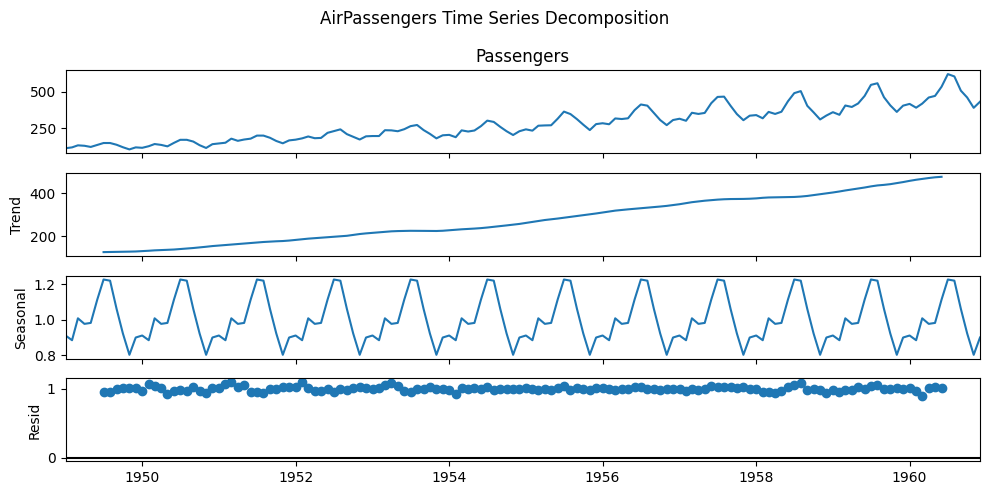

In [ ]:
# Decomposing the time series into observed, trend, seasonal, and residual components
decomposition = seasonal_decompose(
    df["Passengers"],
    model="multiplicative",
    period=12
)

#plotting he decomposiion
fig = decomposition.plot()
fig.set_size_inches(10,5)
fig.suptitle("AirPassengers Time Series Decomposition")
fig.tight_layout()
plt.show()

Observed: The original series shows both increasing trend and repeated yearly seasonality.

Trend: The trend component shows long-term growth in passenger numbers.

Seasonal: The seasonal component shows a repeated 12-month pattern, meaning some months consistently have higher or lower passenger numbers.

Residual: The residual component contains the leftover random variation after removing trend and seasonality.

### Explanation of Multiplicative Decomposition Figure

When using the `seasonal_decompose` function with the `multiplicative` model, the time series is broken down into these four subplots:

1.  **Observed**: This is the original time series data (`df["Passengers"]`). It clearly shows the increasing number of passengers over time (trend) and the repeating yearly patterns (seasonality).

2.  **Trend**: This component captures the underlying long-term direction of the series, effectively smoothing out both seasonal and irregular fluctuations. You can see a strong upward curve, indicating a consistent growth in airline passengers over the years.

3.  **Seasonal**: This component isolates the recurring patterns that happen within a fixed period (12 months in this case). A key characteristic of the *multiplicative* model is that the amplitude of these seasonal fluctuations *increases* as the trend increases. Notice how the peaks and troughs of the seasonal component become larger over time, reflecting that the seasonal variations are proportional to the overall level of the series.

4.  **Residual**: This component represents the remaining variability in the series after the trend and seasonal effects have been removed. In a well-fitted multiplicative model, the residuals should ideally show no clear pattern and resemble white noise, implying that the trend and seasonal components have successfully captured the systematic variations in the data.

#####Fix it — apply differencing, re-test

In [ ]:
# Applying first differencing to **remove trend**
df["first_diff"] = df["Passengers"].diff()

# Applying seasonal differencing to **remove yearly seasonality**
df["seasonal_diff"] = df["Passengers"].diff(12)

# Applying both first differencing and seasonal differencing
df["first_then_seasonal_diff"] = df["Passengers"].diff().diff(12)

display(df.tail(15))

,Passengers,first_diff,seasonal_diff,first_then_seasonal_diff
Month,,,,
1959-10-01,407,-56.0,48.0,-11.0
1959-11-01,362,-45.0,52.0,4.0
1959-12-01,405,43.0,68.0,16.0
1960-01-01,417,12.0,57.0,-11.0
1960-02-01,391,-26.0,49.0,-8.0
1960-03-01,419,28.0,13.0,-36.0
1960-04-01,461,42.0,65.0,52.0
1960-05-01,472,11.0,52.0,-13.0
1960-06-01,535,63.0,63.0,11.0


#####Plot differenced series

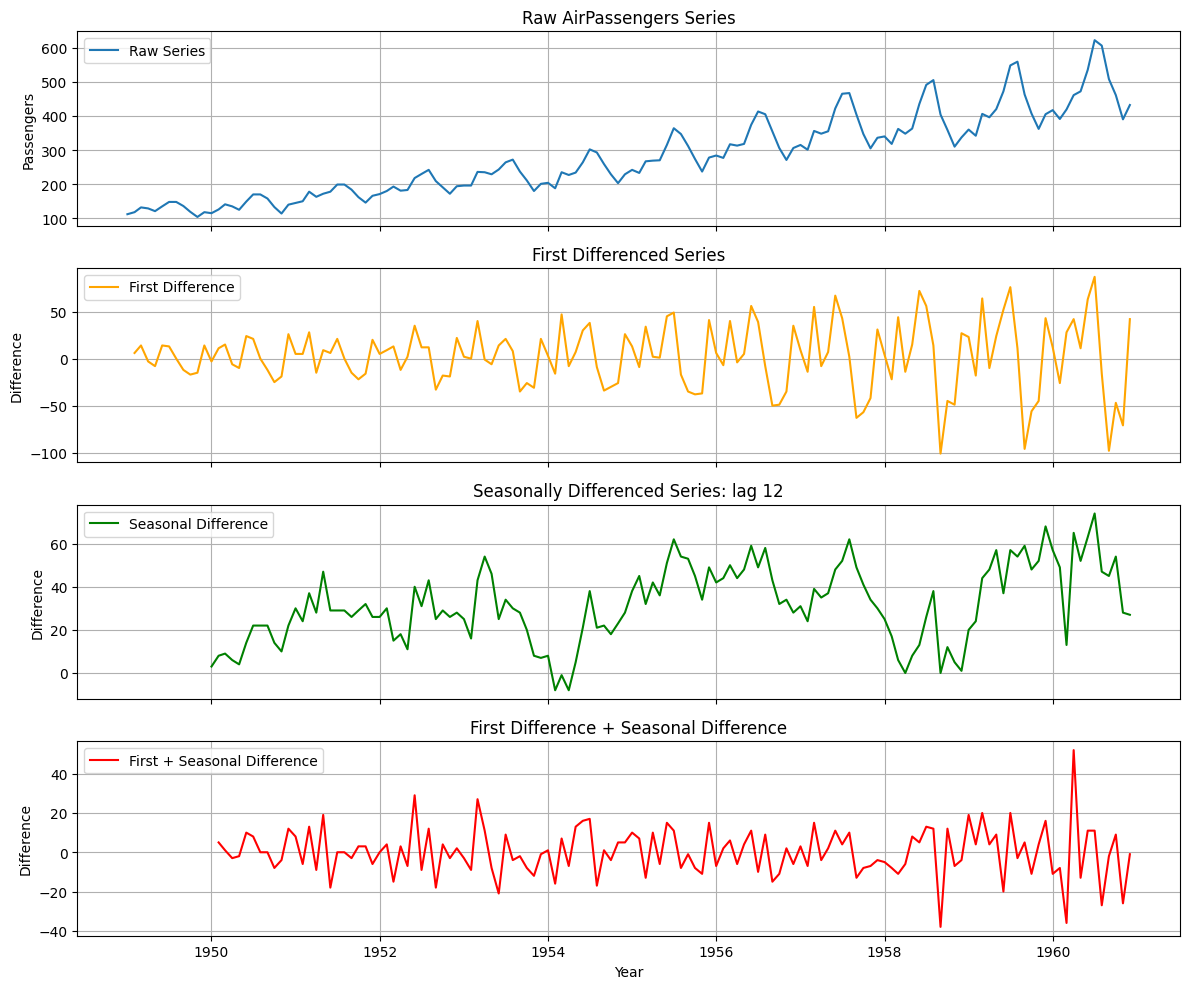

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Plot Raw Series
axes[0].plot(df.index, df["Passengers"], label="Raw Series")
axes[0].set_title("Raw AirPassengers Series")
axes[0].set_ylabel("Passengers")
axes[0].grid(True)
axes[0].legend(loc='upper left')

# Plot First Differenced Series
axes[1].plot(df.index, df["first_diff"], label="First Difference", color="orange")
axes[1].set_title("First Differenced Series")
axes[1].set_ylabel("Difference")
axes[1].grid(True)
axes[1].legend(loc='upper left')

# Plot Seasonal Differenced Series (lag 12)
axes[2].plot(df.index, df["seasonal_diff"], label="Seasonal Difference", color="green")
axes[2].set_title("Seasonally Differenced Series: lag 12")
axes[2].set_ylabel("Difference")
axes[2].grid(True)
axes[2].legend(loc='upper left')

# Plot First Difference + Seasonal Difference
axes[3].plot(df.index, df["first_then_seasonal_diff"], label="First + Seasonal Difference", color="red")
axes[3].set_title("First Difference + Seasonal Difference")
axes[3].set_xlabel("Year")
axes[3].set_ylabel("Difference")
axes[3].grid(True)
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()

#####ADF tests afer differencing

In [ ]:
# Running ADF tests on raw and differenced versions
results = []

results.append(adf_report(df["Passengers"], "Raw Series"))
results.append(adf_report(df["first_diff"], "First Difference"))
results.append(adf_report(df["seasonal_diff"], "Seasonal Difference"))
results.append(adf_report(df["first_then_seasonal_diff"], "First + Seasonal Difference"))

# Creating comparison table
adf_comparison = pd.DataFrame(results)

# Formatting p-values
adf_comparison["p-value"] = adf_comparison["p-value"].round(4)
adf_comparison["ADF Statistic"] = adf_comparison["ADF Statistic"].round(3)

display(adf_comparison)

ADF Test Report: Raw Series
ADF Statistic : 0.8154
p-value       : 0.9919
Used Lag      : 13
Observations  : 130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Verdict: Fail to reject H0. The series is likely non-stationary.
ADF Test Report: First Difference
ADF Statistic : -2.8293
p-value       : 0.0542
Used Lag      : 12
Observations  : 130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Verdict: Fail to reject H0. The series is likely non-stationary.
ADF Test Report: Seasonal Difference
ADF Statistic : -3.3830
p-value       : 0.0116
Used Lag      : 1
Observations  : 130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Verdict: Reject H0. The series is likely stationary.
ADF Test Report: First + Seasonal Difference
ADF Statistic : -15.5956
p-value       : 0.0000
Used Lag      : 0
Observations  : 130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Verdict: Reject H0. The series is likely stationary.


,Series,ADF Statistic,p-value,Verdict
0,Raw Series,0.815,0.9919,Non-stationary
1,First Difference,-2.829,0.0542,Non-stationary
2,Seasonal Difference,-3.383,0.0116,Stationary
3,First + Seasonal Difference,-15.596,0.0000,Stationary


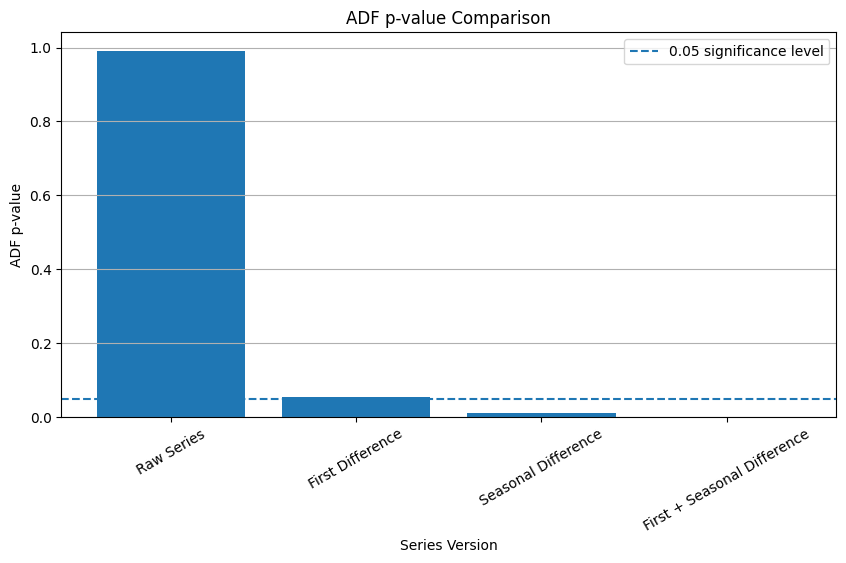

In [ ]:
# Plotting p-value comparison
plt.figure(figsize=(10, 5))
plt.bar(adf_comparison["Series"], adf_comparison["p-value"])
plt.axhline(y=0.05, linestyle="--", label="0.05 significance level")
plt.title("ADF p-value Comparison")
plt.xlabel("Series Version")
plt.ylabel("ADF p-value")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.legend()
plt.show()

Multiplicative decomposition is correct here because the seasonal fluctuations become larger as the passenger level increases. In other words, the size of the seasonal effect grows with the trend, so the seasonal pattern is proportional to the level of the series.

The differencing results suggest that the series needs first differencing to remove trend and seasonal differencing with period 12 to remove yearly seasonality. Therefore, for a SARIMA model, this suggests d = 1 and D = 1 with seasonal period s = 12.

Next, I would inspect the ACF and PACF plots of the differenced series to choose possible SARIMA values for p, q, P, and Q.

##### ACF and PACF plotting

<Figure size 1000x500 with 0 Axes>

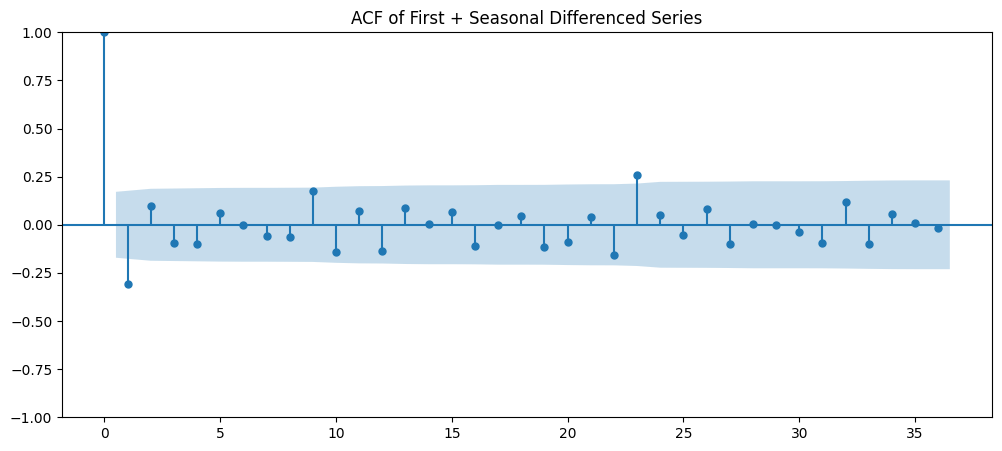

<Figure size 1000x500 with 0 Axes>

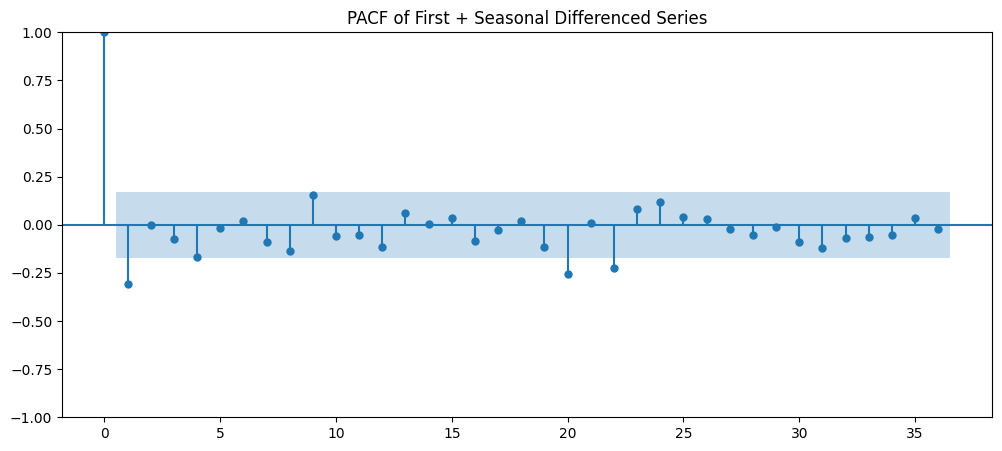

In [ ]:
# Plotting ACF and PACF for the final differenced series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stationary_series = df["first_then_seasonal_diff"].dropna()

plt.figure(figsize=(10, 5))
plot_acf(stationary_series, lags=36)
plt.title("ACF of First + Seasonal Differenced Series")
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(stationary_series, lags=36, method="ywm")
plt.title("PACF of First + Seasonal Differenced Series")
plt.show()

The AirPassengers series is not stationary in its raw form because it has a clear upward trend and strong yearly seasonality. The ADF test confirms this because the raw p-value is greater than 0.05.

After applying first differencing and seasonal differencing, the series becomes much closer to stationary. This suggests that a SARIMA model with d = 1, D = 1, and seasonal period s = 12 is appropriate. The next step is to inspect ACF and PACF plots to select p, q, P, and Q.